In [ ]:
FREEZE = True

# Set FREEZE = True to prevent the execution of code blocks wrapped in `if not FREEZE:`
# Set FREEZE = False to allow them to execute.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

import xgboost as xgb

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the cleaned CICIDS2017 dataset (already preprocessed and label-encoded)
df = pd.read_csv("/content/drive/MyDrive/flowwatch/data/cleaned.csv")
print(f"Shape: {df.shape}")
print()
print(df.head())

Shape: (2520798, 79)

   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0             54865              3                  2                       0   
1             55054            109                  1                       1   
2             55055             52                  1                       1   
3             46236             34                  1                       1   
4             54863              3                  2                       0   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                           12                            0   
1                            6                            6   
2                            6                            6   
3                            6                            6   
4                           12                            0   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0                      6             

In [ ]:
# Class distribution
print("Class distribution:")
print(df["Label"].value_counts())

Class distribution:
Label
0     2095057
4      172846
2      128014
10      90694
3       10286
7        5931
6        5385
5        5228
11       3219
1        1948
12       1470
14        652
9          36
13         21
8          11
Name: count, dtype: int64


In [ ]:
# Split features and target
X = df.drop(columns=["Label"])
y = df["Label"]

feature_names = X.columns.tolist()

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (2016638, 78), Test: (504160, 78)


In [ ]:
# Compute sample weights to handle class imbalance
# (gives higher weight to rare attack types)
# so the model can't ignore them by predicting BENIGN for everything
class_counts = y_train.value_counts()
total = len(y_train)
n_classes = len(class_counts)
class_weight_map = {c: total / (n_classes * count) for c, count in class_counts.items()}
sample_weights = y_train.map(class_weight_map)

print("Class weights:")
for c, w in sorted(class_weight_map.items()):
    print(f"  class {c}: {w:.4f}")

Class weights:
  class 0: 0.0802
  class 1: 86.2917
  class 2: 1.3128
  class 3: 16.3377
  class 4: 0.9723
  class 5: 32.1479
  class 6: 31.2076
  class 7: 28.3335
  class 8: 14938.0593
  class 9: 4635.9494
  class 10: 1.8530
  class 11: 52.2107
  class 12: 114.3219
  class 13: 7908.3843
  class 14: 257.5527


In [ ]:
# ====================== BASELINE XGBoost ======================
print("=== BASELINE XGBoost ===")

model = xgb.XGBClassifier(
    device="cuda", # train on GPU instead
    objective="multi:softprob",
    num_class=n_classes,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric="mlogloss"
)

model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred))

=== BASELINE XGBoost ===


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [12:59:24] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Accuracy : 0.9950
F1 (macro): 0.7959
ROC AUC  : 0.9999

              precision    recall  f1-score   support

           0       1.00      0.99      1.00    419012
           1       0.28      1.00      0.44       390
           2       1.00      1.00      1.00     25603
           3       0.95      1.00      0.97      2057
           4       0.98      1.00      0.99     34569
           5       0.94      1.00      0.97      1046
           6       0.98      0.99      0.99      1077
           7       0.99      1.00      1.00      1186
           8       0.67      1.00      0.80         2
           9       0.32      1.00      0.48         7
          10       0.99      1.00      0.99     18139
          11       0.98      1.00      0.99       644
          12       0.58      0.62      0.60       294
          13       0.20      1.00      0.33         4
          14       0.26      0.77      0.38       130

    accuracy                           1.00    504160
   macro avg       0.74 

In [ ]:
%pip install optuna -q

In [ ]:
import optuna

# ====================== OPTUNA HYPERPARAMETER TUNING ======================
print("=== STARTING OPTUNA TUNING ===")

# Stratified subsample 15% of training data for faster tuning
from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, train_size=0.15, random_state=42)
tune_idx, _ = next(sss.split(X_train, y_train))
X_tune = X_train.iloc[tune_idx]
y_tune = y_train.iloc[tune_idx]
sw_tune = sample_weights.iloc[tune_idx]
print(f"Tuning on {len(X_tune):,} rows (15% of train, stratified)")

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5.0),
        "objective": "multi:softprob",
        "num_class": n_classes,
        "eval_metric": "mlogloss",
        "tree_method": "hist",
        "device": "cuda",
        "random_state": 42,
        "verbosity": 0,
        "early_stopping_rounds": 30,
    }

    clf = xgb.XGBClassifier(**params)
    clf.fit(
        X_tune, y_tune,
        sample_weight=sw_tune,
        eval_set=[(X_test, y_test)],
        verbose=False,
    )

    y_prob = clf.predict_proba(X_test)
    return roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print(f"Best ROC AUC: {study.best_value:.4f}")
print(f"Best parameters: {study.best_params}")

=== STARTING OPTUNA TUNING ===


[I 2026-05-05 12:59:38,236] A new study created in memory with name: no-name-c66c1e1f-268e-4fff-a923-2c776be74268


Tuning on 302,495 rows (15% of train, stratified)


[I 2026-05-05 13:00:04,713] Trial 0 finished with value: 0.9993343936933258 and parameters: {'n_estimators': 115, 'max_depth': 3, 'learning_rate': 0.033331228281239786, 'subsample': 0.7624672819999916, 'colsample_bytree': 0.6756123001195005, 'gamma': 3.3580354319497614, 'reg_lambda': 9.592543820444847, 'reg_alpha': 3.4903360137115707}. Best is trial 0 with value: 0.9993343936933258.
[I 2026-05-05 13:00:18,732] Trial 1 finished with value: 0.9976599830571877 and parameters: {'n_estimators': 84, 'max_depth': 3, 'learning_rate': 0.018245253468019404, 'subsample': 0.937833167502968, 'colsample_bytree': 0.9117681178143993, 'gamma': 0.5558443052213452, 'reg_lambda': 3.5721609174448874, 'reg_alpha': 3.401230625702021}. Best is trial 0 with value: 0.9993343936933258.
[I 2026-05-05 13:00:48,888] Trial 2 finished with value: 0.9994752785453013 and parameters: {'n_estimators': 280, 'max_depth': 6, 'learning_rate': 0.0736945998516969, 'subsample': 0.6463256862070459, 'colsample_bytree': 0.74510833

Best ROC AUC: 0.9998
Best parameters: {'n_estimators': 384, 'max_depth': 5, 'learning_rate': 0.025922078016299983, 'subsample': 0.8201763418050431, 'colsample_bytree': 0.7859696575146378, 'gamma': 1.9878417153744592, 'reg_lambda': 6.448340783218639, 'reg_alpha': 1.283240601218448}


In [ ]:
# ====================== FINAL OPTIMIZED MODEL ======================
print("=== FINAL OPTIMIZED XGBoost ===")

best_params = study.best_params.copy()
best_params.pop("early_stopping_rounds", None)
best_params.update({
    "objective": "multi:softprob",
    "num_class": n_classes,
    "eval_metric": "mlogloss",
    "random_state": 42,
    "verbosity": 0,
    "device": "cuda",
    "tree_method": "hist",
    "n_estimators": 300,
})

import time

class FitProgressCallback(xgb.callback.TrainingCallback):
    def __init__(self, total, log_every=25):
        self.total = total
        self.log_every = log_every
        self.start = None

    def after_iteration(self, model, epoch, evals_log):
        if self.start is None:
            self.start = time.time()
        n = epoch + 1
        if n == 1 or n % self.log_every == 0 or n == self.total:
            elapsed = time.time() - self.start
            rate = n / elapsed if elapsed > 0 else 0
            remaining = (self.total - n) / rate if rate > 0 else 0
            print(
                f"  [{n:>3}/{self.total}] "
                f"elapsed: {elapsed:.1f}s  "
                f"~{remaining:.0f}s remaining  "
                f"({rate:.1f} trees/s)"
            )
        return False  # returning True would stop training early

print(f"Training XGBoost — {best_params['n_estimators']} trees  |  "
      f"max_depth={best_params['max_depth']}  |  "
      f"lr={best_params['learning_rate']:.4f}")
print(f"Train size: {X_train.shape[0]:,} rows × {X_train.shape[1]} features")
print()

t0 = time.time()
final_model = xgb.XGBClassifier(
    **best_params,
    callbacks=[FitProgressCallback(total=best_params["n_estimators"], log_every=25)],
)
final_model.fit(X_train, y_train, sample_weight=sample_weights)
print(f"\nFit complete in {time.time() - t0:.1f}s")

print("\nRunning predictions...")
t1 = time.time()
y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)
print(f"Predictions done in {time.time() - t1:.2f}s")

print(f"\nAccuracy  : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"F1 (macro): {f1_score(y_test, y_pred_final, average='macro'):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, y_prob_final, multi_class='ovr', average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred_final))

=== FINAL OPTIMIZED XGBoost ===
Training XGBoost — 300 trees  |  max_depth=5  |  lr=0.0259
Train size: 2,016,638 rows × 78 features

  [  1/300] elapsed: 0.0s  ~0s remaining  (419430.4 trees/s)
  [ 25/300] elapsed: 7.8s  ~86s remaining  (3.2 trees/s)
  [ 50/300] elapsed: 16.5s  ~83s remaining  (3.0 trees/s)
  [ 75/300] elapsed: 26.1s  ~78s remaining  (2.9 trees/s)
  [100/300] elapsed: 35.7s  ~71s remaining  (2.8 trees/s)
  [125/300] elapsed: 45.3s  ~63s remaining  (2.8 trees/s)
  [150/300] elapsed: 54.9s  ~55s remaining  (2.7 trees/s)
  [175/300] elapsed: 64.5s  ~46s remaining  (2.7 trees/s)
  [200/300] elapsed: 74.2s  ~37s remaining  (2.7 trees/s)
  [225/300] elapsed: 84.6s  ~28s remaining  (2.7 trees/s)
  [250/300] elapsed: 94.6s  ~19s remaining  (2.6 trees/s)
  [275/300] elapsed: 104.4s  ~9s remaining  (2.6 trees/s)
  [300/300] elapsed: 114.3s  ~0s remaining  (2.6 trees/s)

Fit complete in 151.0s

Running predictions...
Predictions done in 4.79s

Accuracy  : 0.9955
F1 (macro): 0.798

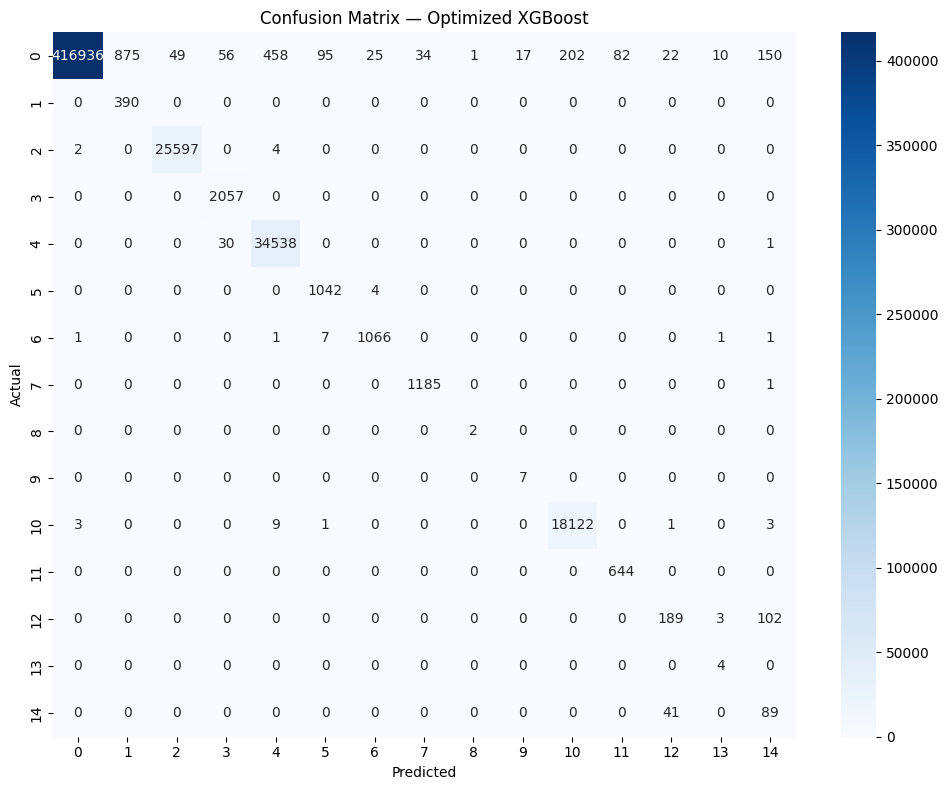

In [ ]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Optimized XGBoost")
plt.tight_layout()
plt.show()

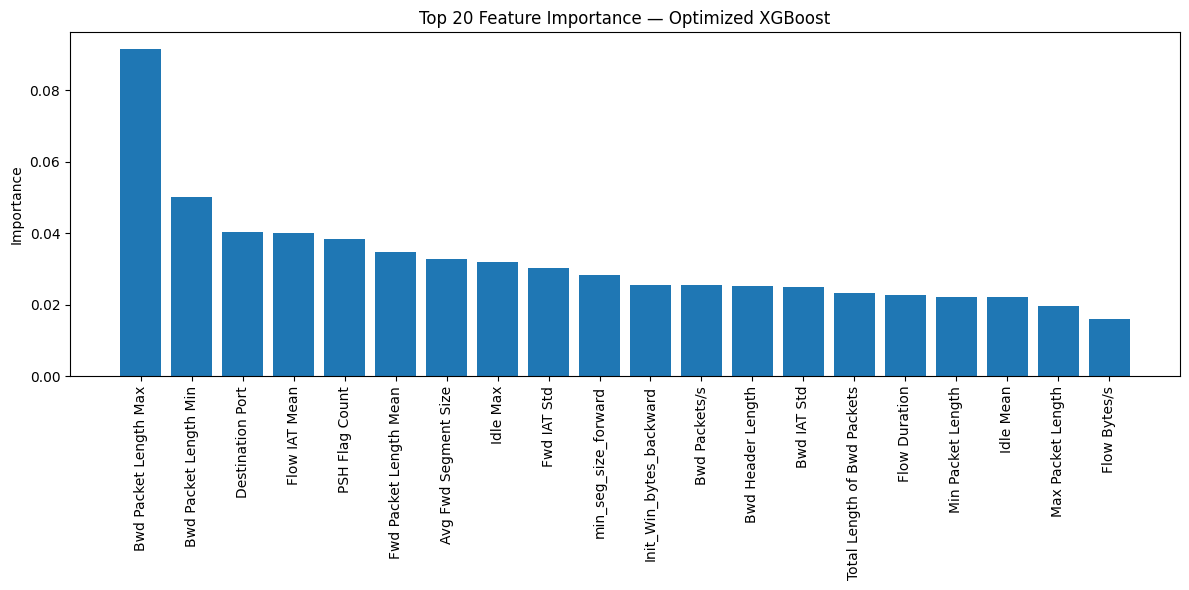

In [ ]:
# Feature importance (top 20)
importances = final_model.feature_importances_
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 6))
plt.title("Top 20 Feature Importance — Optimized XGBoost")
plt.bar(range(20), importances[indices])
plt.xticks(range(20), [feature_names[i] for i in indices], rotation=90)
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go

label_names = {
    0: "BENIGN", 1: "Bot", 2: "DDoS", 3: "DoS GoldenEye",
    4: "DoS Hulk", 5: "DoS Slowhttptest", 6: "DoS slowloris",
    7: "FTP-Patator", 8: "Heartbleed", 9: "Infiltration",
    10: "PortScan", 11: "SSH-Patator", 12: "Web Attack – Brute Force",
    13: "Web Attack – SQL Injection", 14: "Web Attack – XSS"
}

n_sample = 2000
sample_dfs = []
for label in df["Label"].unique():  # was y.unique()
    group = df[df["Label"] == label]
    n = min(len(group), max(n_sample // n_classes, 2))
    sample_dfs.append(group.sample(n=n, random_state=42))
tsne_df = pd.concat(sample_dfs)

X_tsne = tsne_df.drop(columns=["Label"])
y_tsne = tsne_df["Label"]

top_features = [feature_names[i] for i in np.argsort(final_model.feature_importances_)[::-1][:20]]
X_tsne_top = X_tsne[top_features]

X_scaled = StandardScaler().fit_transform(X_tsne_top)

tsne = TSNE(n_components=3, perplexity=30, random_state=42, max_iter=1000)
embedding = tsne.fit_transform(X_scaled)

fig = go.Figure()
for label in sorted(y_tsne.unique()):
    mask = y_tsne.values == label
    fig.add_trace(go.Scatter3d(
        x=embedding[mask, 0],
        y=embedding[mask, 1],
        z=embedding[mask, 2],
        mode="markers",
        name=label_names.get(label, str(label)),
        marker=dict(size=3, opacity=0.7),
    ))

fig.update_layout(
    title="3D t-SNE — Top 20 Features (stratified sample)",
    scene=dict(
        xaxis_title="t-SNE 1",
        yaxis_title="t-SNE 2",
        zaxis_title="t-SNE 3",
    ),
    legend=dict(x=1.01, y=1, font=dict(size=11)),
    margin=dict(l=0, r=0, b=0, t=40),
    width=1000,
    height=750,
)

fig.show()

In [ ]:
%pip install plotly onnxmltools nbformat skl2onnx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.0/304.0 kB 10.5 MB/s eta 0:00:00


In [ ]:
from onnxmltools.convert.xgboost.operator_converters.XGBoost import convert_xgboost
from skl2onnx import update_registered_converter, convert_sklearn
from skl2onnx.common.shape_calculator import calculate_linear_classifier_output_shapes
from skl2onnx.common.data_types import FloatTensorType
import json

update_registered_converter(
    xgb.XGBClassifier,
    "XGBoostXGBClassifier",
    calculate_linear_classifier_output_shapes,
    convert_xgboost,
    options={"nocl": [True, False], "zipmap": [True, False]},
)

# Retrain a copy of the model with sanitized feature names
safe_feature_names = [f"f{i}" for i in range(len(feature_names))]
X_train_safe = X_train.copy()
X_train_safe.columns = safe_feature_names

final_model_safe = xgb.XGBClassifier(**best_params)
final_model_safe.fit(X_train_safe, y_train, sample_weight=sample_weights)

# Convert to ONNX using sanitized names
onnx_model = convert_sklearn(
    final_model_safe,
    "flowwatch",
    [("input", FloatTensorType([None, len(safe_feature_names)]))],
    target_opset={"": 12, "ai.onnx.ml": 3},
    options={type(final_model_safe): {"zipmap": False}},
)

with open("/content/drive/MyDrive/flowwatch/data/flowwatch.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

# Save metadata with the real feature names (for inference mapping)
metadata = {
    "feature_names": feature_names,
    "safe_feature_names": safe_feature_names,
    "label_names": {str(k): v for k, v in label_names.items()}
}
with open("/content/drive/MyDrive/flowwatch/data/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved model to /content/drive/MyDrive/flowwatch/data/flowwatch.onnx")
print("Saved metadata to /content/drive/MyDrive/flowwatch/data/metadata.json")

Saved model to /content/drive/MyDrive/flowwatch/data/flowwatch.onnx
Saved metadata to /content/drive/MyDrive/flowwatch/data/metadata.json


In [3]:
import pickle
from google.colab import drive
drive.mount('/content/drive')

import pickle
with open("/content/drive/MyDrive/flowwatch/data/xgboost_model.pkl", "wb") as f:
    pickle.dump(final_model, f)


Mounted at /content/drive


NameError: name 'final_model' is not defined